In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
from PIL import Image

In [2]:
# Locate the ZIP file in the Kaggle input directory
input_dir = r"D:\Major Project\train"
zip_filename = None

In [3]:
input_dir = r"D:\Major Project\train"

# List all files and directories
for dirname, subdirs, filenames in os.walk(input_dir):
    print(f"Directory: {dirname}")
    for filename in filenames:
        print(f"  File: {filename}")

In [4]:
# Debug Step 1: Print extracted files
print("Extracted files and folders:")
for root, dirs, files in os.walk(r"D:\Major Project\train"):
    print(f"Directory: {root}, Subdirectories: {dirs}, Files: {files}")

Extracted files and folders:


In [5]:
# Define label mapping
label_mapping = {"angry": 1, "happy": 2, "surprise": 3}

# Initialize dataset
data = []
print(label_mapping)

{'angry': 1, 'happy': 2, 'surprise': 3}


In [16]:
# Debug Step 2: Check if labeled folders exist
print("\nChecking for labeled folders:")
for label_name in label_mapping.keys():
    folder_path = os.path.join(r"D:\Jupyter\Major Project\train", label_name)
    if os.path.exists(folder_path):
        print(f"✅ Found folder: {label_name}")
    else:
        print(f"❌ Missing folder: {label_name}")


Checking for labeled folders:
✅ Found folder: angry
✅ Found folder: happy
✅ Found folder: surprise


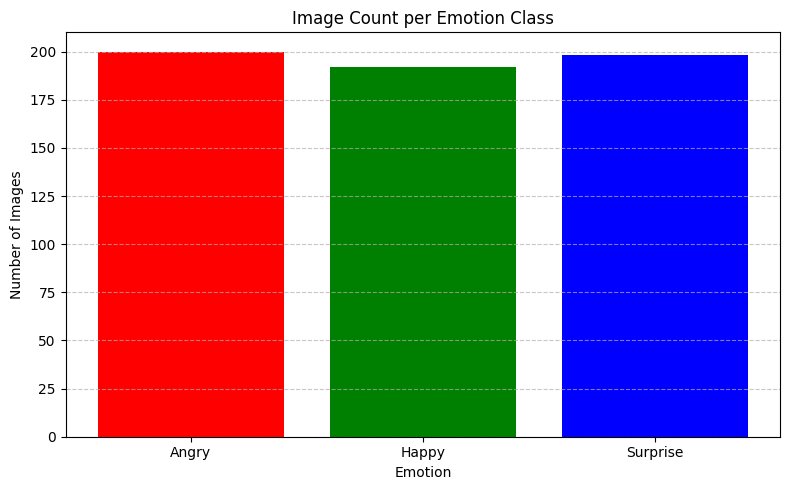

In [17]:
import matplotlib.pyplot as plt

# Define label names and folder path
base_path = r"D:\Jupyter\Major Project\train"
labels = ['angry', 'happy', 'surprise']
image_counts = {}

# Count images in each folder
for label in labels:
    folder_path = os.path.join(base_path, label)
    if os.path.exists(folder_path):
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        image_counts[label.capitalize()] = len(image_files)
    else:
        image_counts[label.capitalize()] = 0

# Plotting the bar chart
plt.figure(figsize=(8, 5))
plt.bar(image_counts.keys(), image_counts.values(), color=['red', 'green', 'blue'])
plt.title('Image Count per Emotion Class')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [24]:
# Read images and assign labels
for label_name, label in label_mapping.items():
    folder_path = os.path.join(r"D:\Jupyter\Major Project\train", label_name)

    if os.path.exists(folder_path):
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((64, 64))  # Resize to standard size
                img_array = np.array(img).flatten()  # Flatten image
                data.append([img_name, label] + img_array.tolist())
            except Exception as e:
                print(f"Error processing {img_name}: {e}")

In [25]:
# Convert to DataFrame
df = pd.DataFrame(data, columns=["Image_Name", "Label"] + [f"pixel_{i}" for i in range(64*64*3)])

In [26]:
print(df)

                Image_Name  Label  pixel_0  pixel_1  pixel_2  pixel_3  \
0    Training_39444833.jpg      1      140      140      140      150   
1    Training_39456208.jpg      1       19       19       19       19   
2    Training_39520111.jpg      1      195      195      195      192   
3    Training_39536203.jpg      1      122      122      122      111   
4    Training_39537307.jpg      1      222      222      222      214   
..                     ...    ...      ...      ...      ...      ...   
585  Training_76005545.jpg      3      116      116      116       72   
586  Training_76055798.jpg      3      255      255      255      196   
587  Training_76086118.jpg      3      167      167      167      164   
588  Training_76099398.jpg      3       19       19       19       20   
589  Training_76105973.jpg      3      207      207      207      119   

     pixel_4  pixel_5  pixel_6  pixel_7  ...  pixel_12278  pixel_12279  \
0        150      150      145      145  ...     

In [27]:
# Debug: Print first few rows
print("\n📊 Sample Data:")
print(df.head())


📊 Sample Data:
              Image_Name  Label  pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  \
0  Training_39444833.jpg      1      140      140      140      150      150   
1  Training_39456208.jpg      1       19       19       19       19       19   
2  Training_39520111.jpg      1      195      195      195      192      192   
3  Training_39536203.jpg      1      122      122      122      111      111   
4  Training_39537307.jpg      1      222      222      222      214      214   

   pixel_5  pixel_6  pixel_7  ...  pixel_12278  pixel_12279  pixel_12280  \
0      150      145      145  ...           77           80           80   
1       19       19       19  ...           13            3            3   
2      192      191      191  ...          231          232          232   
3      111       95       95  ...          208          213          213   
4      214      204      204  ...           55           69           69   

   pixel_12281  pixel_12282  pixel_12283  pixe

In [28]:
# Debug: Print total images processed
print(f"\n✅ Total images processed: {len(df)}")


✅ Total images processed: 590


In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [33]:
# Path to the training data
data_dir = r"D:\Jupyter\Major Project\train"
img_size = 48
batch_size = 32



datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=batch_size,
    subset='validation',
    shuffle=False
)

# CNN model for emotion detection
image_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

image_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# 🔁 Train the model for 15 epochs
image_model.fit(train_gen, validation_data=val_gen, epochs=15)

# 💾 Save the trained model
image_model.save("emotion_model.h5")

# 📊 Evaluate on validation set
test_loss, test_acc = image_model.evaluate(val_gen)
print(f"📊 Validation Accuracy: {test_acc * 100:.2f}%")


Found 473 images belonging to 3 classes.
Found 117 images belonging to 3 classes.
Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3287 - loss: 1.1346 - val_accuracy: 0.4530 - val_loss: 1.0938
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3998 - loss: 1.0865 - val_accuracy: 0.4615 - val_loss: 1.0807
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4912 - loss: 1.0526 - val_accuracy: 0.4615 - val_loss: 1.0727
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5152 - loss: 1.0310 - val_accuracy: 0.3590 - val_loss: 1.0806
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5177 - loss: 0.9741 - val_accuracy: 0.4786 - val_loss: 1.0332
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6074 - loss: 0.8640 - val_accuracy: 0.4786 - val_loss: 1.0577
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6300 - loss: 0.8538 - val_accuracy: 0.4872 - val_loss: 1.0127
Epoch 8/15
15/15 ━━━━━━━━━━━━

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5399 - loss: 1.1151
📊 Validation Accuracy: 55.56%


In [34]:
# 🔍 Evaluate the model on the validation data
test_loss, test_acc = image_model.evaluate(val_gen)
print(f"📊 Validation Accuracy: {test_acc * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5399 - loss: 1.1151
📊 Validation Accuracy: 55.56%
